# Случайный лес (Random Forest)

В программе:
* обучение леса и сравнение с деревом
* подбор гиперпараметров леса
* зависимость качества от числа деревьев

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.datasets import fetch_california_housing

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score

In [2]:
RANDOM_STATE = 42

In [3]:
data = fetch_california_housing(as_frame=True)

X = data.data
y = data.target

## 1. Сравнение дерева и леса

In [4]:
dt = DecisionTreeRegressor()

cross_val_score(dt, X, y, cv=3, scoring='r2').mean()

np.float64(0.3295024410946052)

In [5]:
rf = RandomForestRegressor()

cross_val_score(rf, X, y, cv=3, scoring='r2').mean()

np.float64(0.6539792847763262)

## 2. Подбор гиперпараметров леса

Для подбора гиперпараметров модели лучше всего действовать так:
* разбиваем данные на *train* и *test*
* на *train* по кросс-валидации при помощи `GridSearchCV` ищем наилучшие гиперпараметры модели
* оцениваем качество модели с наилучшими гиперпараметрами на *test*

In [6]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE)

### Гиперпараметры леса (random forest)

* `n_estimators=100` - число деревьев в лесе
* `oob_score=False` - вычисляем ли out-of-bag ошибку
* `n_jobs=None` - на сколько процессов распараллеливаем вычисления
* гиперпараметры деревьев (обсуждали раньше):
  + `criterion='squared_error'`
  + `max_depth=None`
  + `min_samples_split=2`
  + ...
  + `random_state=None`

In [19]:
params = {'n_estimators': np.arange(10, 200, 20),
          'max_depth': np.arange(2, 20, 3)}

gs = GridSearchCV(RandomForestRegressor(), params, cv=3, scoring='r2', verbose=2)

gs.fit(Xtrain, ytrain)

Fitting 3 folds for each of 60 candidates, totalling 180 fits
[CV 1/3] END ......max_depth=2, n_estimators=10;, score=0.468 total time=   0.0s
[CV 2/3] END ......max_depth=2, n_estimators=10;, score=0.471 total time=   0.0s
[CV 3/3] END ......max_depth=2, n_estimators=10;, score=0.457 total time=   0.0s
[CV 1/3] END ......max_depth=2, n_estimators=30;, score=0.461 total time=   0.1s
[CV 2/3] END ......max_depth=2, n_estimators=30;, score=0.472 total time=   0.1s
[CV 3/3] END ......max_depth=2, n_estimators=30;, score=0.460 total time=   0.1s
[CV 1/3] END ......max_depth=2, n_estimators=50;, score=0.461 total time=   0.3s
[CV 2/3] END ......max_depth=2, n_estimators=50;, score=0.473 total time=   0.3s
[CV 3/3] END ......max_depth=2, n_estimators=50;, score=0.463 total time=   0.3s
[CV 1/3] END ......max_depth=2, n_estimators=70;, score=0.460 total time=   0.5s
[CV 2/3] END ......max_depth=2, n_estimators=70;, score=0.472 total time=   0.5s
[CV 3/3] END ......max_depth=2, n_estimators=70

KeyboardInterrupt: 

In [20]:
params = {'n_estimators': np.arange(150, 200, 40),
          'max_depth': [17]}

gs = GridSearchCV(RandomForestRegressor(), params, cv=3, scoring='r2', verbose=3)

gs.fit(Xtrain, ytrain)

Fitting 3 folds for each of 2 candidates, totalling 6 fits
[CV 1/3] END ....max_depth=17, n_estimators=150;, score=0.784 total time=   6.4s
[CV 2/3] END ....max_depth=17, n_estimators=150;, score=0.799 total time=   6.4s
[CV 3/3] END ....max_depth=17, n_estimators=150;, score=0.790 total time=   6.4s
[CV 1/3] END ....max_depth=17, n_estimators=190;, score=0.785 total time=   8.2s
[CV 2/3] END ....max_depth=17, n_estimators=190;, score=0.801 total time=   8.1s
[CV 3/3] END ....max_depth=17, n_estimators=190;, score=0.792 total time=   8.2s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [17], 'n_estimators': array([150, 190])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold

In [21]:
gs.best_score_, gs.best_estimator_

(np.float64(0.7924397756671633),
 RandomForestRegressor(max_depth=17, n_estimators=np.int64(190)))

In [15]:
params = {'max_features': [None, 'sqrt', 'log2']}

gs = GridSearchCV(RandomForestRegressor(n_estimators = 190, max_depth = 17), params, cv=3, scoring='r2', verbose=2)

gs.fit(Xtrain, ytrain)

Fitting 3 folds for each of 3 candidates, totalling 9 fits
[CV] END ..................................max_features=None; total time=   8.3s
[CV] END ..................................max_features=None; total time=   8.1s
[CV] END ..................................max_features=None; total time=   8.1s
[CV] END ..................................max_features=sqrt; total time=   2.6s
[CV] END ..................................max_features=sqrt; total time=   2.6s
[CV] END ..................................max_features=sqrt; total time=   2.6s
[CV] END ..................................max_features=log2; total time=   3.6s
[CV] END ..................................max_features=log2; total time=   3.6s
[CV] END ..................................max_features=log2; total time=   3.6s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...stimators=190)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_features': [None, 'sqrt', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candi

In [16]:
gs_190_score = gs.best_score_
gs_190_est = gs.best_estimator_

Теперь проверим полученную модель на тестовых данных

In [18]:
print(gs_150_score, gs_150_est)
print(gs_190_score, gs_190_est)

0.8057413562006004 RandomForestRegressor(max_depth=17, max_features='log2', n_estimators=150)
0.8069710971404009 RandomForestRegressor(max_depth=17, max_features='log2', n_estimators=190)


In [22]:
model = RandomForestRegressor(n_estimators = 190, max_depth = 17, max_features='log2')

model.fit(Xtrain, ytrain)

pred = model.predict(Xtest)

r2_score(ytest, pred)

0.8148299106779475

## 3. Поведение модели при увеличении числа деревьев

Text(0, 0.5, 'r2')

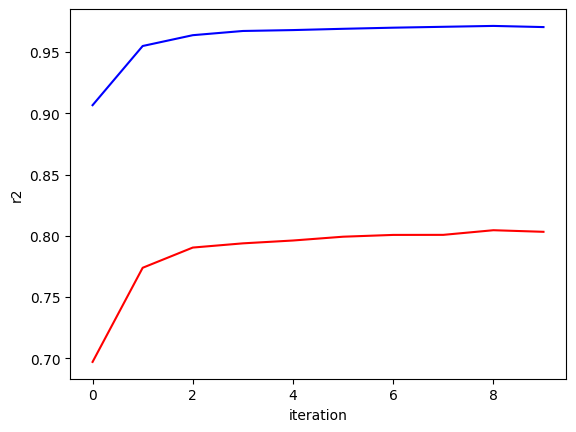

In [23]:
r2_train = []
r2_test = []

for n in range(2, 50, 5):
    model = RandomForestRegressor(n_estimators = n, n_jobs=-1)
    model.fit(Xtrain, ytrain)

    pred_train = model.predict(Xtrain)
    pred_test = model.predict(Xtest)

    r2_train.append(r2_score(ytrain, pred_train))
    r2_test.append(r2_score(ytest, pred_test))

plt.plot(r2_train, color='blue')
plt.plot(r2_test, color='red')
plt.xlabel('iteration')
plt.ylabel('r2')

Эти графики подтверждают теорию: при увеличении числа деревьев в лесе качество тоже только увеличивается.

На практике качество в какой-то момент выходит на асимптоту и начинает увеличиваться совсем незначительно. Поэтому обычно выбирают минимальное число деревьев в лесе, при котором качество уже почти не растет - ведь лес с большим числом деревьев обучается очень долго.